<h2><b>Image Processing and Machine Vision - Assignmet 01</b></h2>



1.Implimentation of the intesity transformation


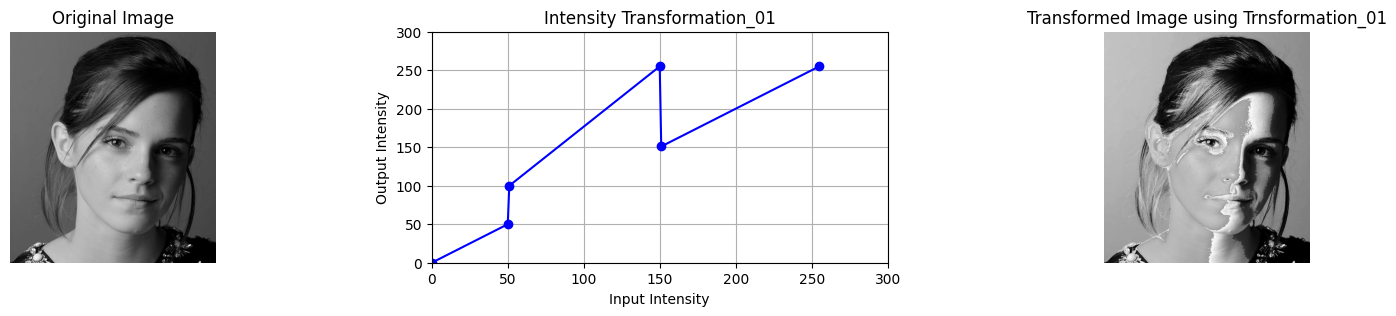

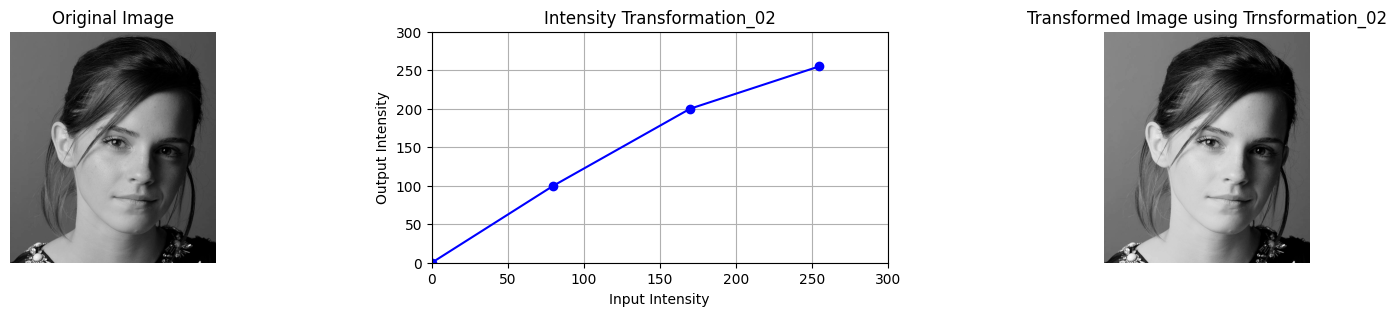

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

breakpoints_1 = [[0,0], [50,50], [51,100], [150,255], [151,151],[255,255]]
breakpoints_2 = [[0, 0], [80, 100], [170, 200], [255, 255]]

x_coords_1 = [x[0] for x in breakpoints_1] # Extracting x-coordinates from the breakpoints_1
y_coords_1 = [x[1] for x in breakpoints_1] # Extracting y-coordinates from the breakpoints_1

x_coords_2 = [x[0] for x in breakpoints_2] # Extracting x-coordinates from the breakpoints_2
y_coords_2 = [x[1] for x in breakpoints_2] # Extracting y-coordinates from the breakpoints_2

def intensity_transform(im, breakpoints):
   
    # Separate into input (x) and output (y) coordinates
    x_coords = [x[0] for x in breakpoints]
    y_coords = [x[1] for x in breakpoints]

    # Apply numpy's linear interpolation
    # im.flatten() makes the 2D image a 1D array so interp can process it
    transformed_flat = np.interp(im.flatten(), x_coords, y_coords)
    
    # Reshape it back to the original image dimensions and ensure it's an 8-bit integer
    transformed_im = transformed_flat.reshape(im.shape).astype(np.uint8)
    
    return transformed_im

im = cv.imread("images\\q1.jpeg", cv.IMREAD_GRAYSCALE)
assert im is not None, "Image not found or unable to open."
transformed_imm_1 = intensity_transform(im, breakpoints_1)

fig , ax = plt.subplots(1,3,figsize = (20,3))
ax[0].imshow(im, cmap = 'gray', vmin = 0, vmax = 255)
ax[0].set_title('Original Image')
ax[0].axis('off')  # Hide axes for the original image


ax[1].plot(x_coords_1, y_coords_1, marker='o', color='blue', linestyle='-')
ax[1].set_title('Intensity Transformation_01')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 300]) # Fixing the axes to standard 8-bit limits
ax[1].set_ylim([0, 300])
ax[1].grid(True) # Adding a grid helps visualize the breakpoints

ax[2].imshow(transformed_imm_1, cmap = 'gray', vmin = 0, vmax = 255)
ax[2].set_title('Transformed Image using Trnsformation_01')
ax[2].axis('off')  # Hide axes for the transformed image

transformed_imm_2 = intensity_transform(im, breakpoints_2)
fig , ax = plt.subplots(1,3,figsize = (20,3))

ax[0].imshow(im, cmap = 'gray', vmin = 0, vmax = 255)
ax[0].set_title('Original Image')
ax[0].axis('off')  # Hide axes for the original image

ax[1].plot(x_coords_2, y_coords_2, marker='o', color='blue', linestyle='-')
ax[1].set_title('Intensity Transformation_02')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 300]) # Fixing the axes to standard 8-bit limits
ax[1].set_ylim([0, 300])
ax[1].grid(True) # Adding a grid helps visualize the breakpoints

ax[2].imshow(transformed_imm_2, cmap = 'gray', vmin = 0, vmax = 255)
ax[2].set_title('Transformed Image using Trnsformation_02')
ax[2].axis('off')  # Hide axes for the transformed image

plt.show()

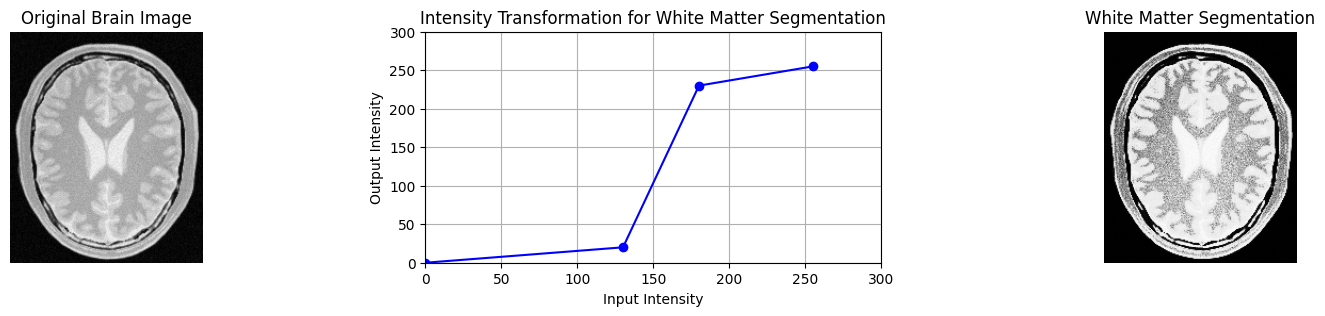

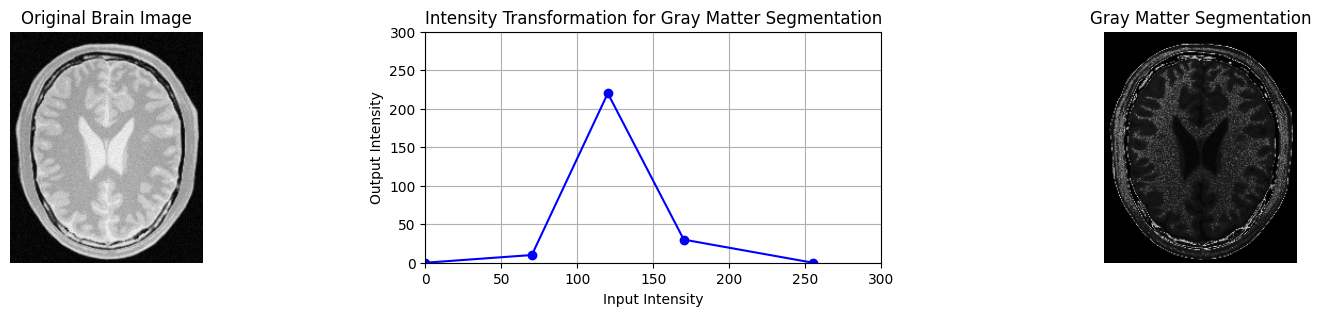

In [3]:
# Breakpoints targeting high intensities (White Matter)
wm_breakpoints = [
    [0, 0],
    [130, 20],   # Suppress CSF(Cerebral Spinal Fluid) and Gray Matter
    [180, 230],  # Steep stretch across White Matter range
    [255, 255]   # Max out bright regions
]
x_coords_wm = [x[0] for x in wm_breakpoints] # Extracting x-coordinates from the wm_breakpoints
y_coords_wm = [x[1] for x in wm_breakpoints] # Extracting y-coordinates from the wm_breakpoints

im_brain = cv.imread("images\\q2.jpeg", cv.IMREAD_GRAYSCALE)
wm_image = intensity_transform(im_brain, wm_breakpoints)

fig, ax = plt.subplots (1, 3, figsize=(20, 3))
ax[0].imshow(im_brain, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Brain Image')     
ax[0].axis('off')  # Hide axes for the original image

ax[1].plot(x_coords_wm, y_coords_wm, marker='o', color='blue', linestyle='-')
ax[1].set_title('Intensity Transformation for White Matter Segmentation')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 300]) # Fixing the axes to standard 8-bit limits
ax[1].set_ylim([0, 300])
ax[1].grid(True) # Adding a grid helps visualize the breakpoints


ax[2].imshow(wm_image, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('White Matter Segmentation')
ax[2].axis('off')  # Hide axes for the transformed image

plt.show()

# Breakpoints targeting mid intensities (Gray Matter)
gm_breakpoints = [
    [0, 0],
    [70, 10],    # Suppress dark background / CSF
    [120, 220],  # Steep stretch across Gray Matter range
    [170, 30],   # Drop bright White Matter to keep Gray Matter visually dominant
    [255, 0]
]

x_coords_gm = [x[0] for x in gm_breakpoints] # Extracting x-coordinates from the gm_breakpoints
y_coords_gm = [x[1] for x in gm_breakpoints] # Extracting y-coordinates from the gm_breakpoints

gm_image = intensity_transform(im_brain, gm_breakpoints)
fig, ax = plt.subplots (1, 3, figsize=(20, 3))
ax[0].imshow(im_brain, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Brain Image')     
ax[0].axis('off')  # Hide axes for the original image

ax[1].plot(x_coords_gm, y_coords_gm, marker='o', color='blue', linestyle='-')
ax[1].set_title('Intensity Transformation for Gray Matter Segmentation')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 300]) # Fixing the axes to standard 8-bit limits
ax[1].set_ylim([0, 300])
ax[1].grid(True) # Adding a grid helps visualize the breakpoints


ax[2].imshow(gm_image, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Gray Matter Segmentation')
ax[2].axis('off')  # Hide axes for the transformed image

plt.show()




2. Gamma correction to L plane

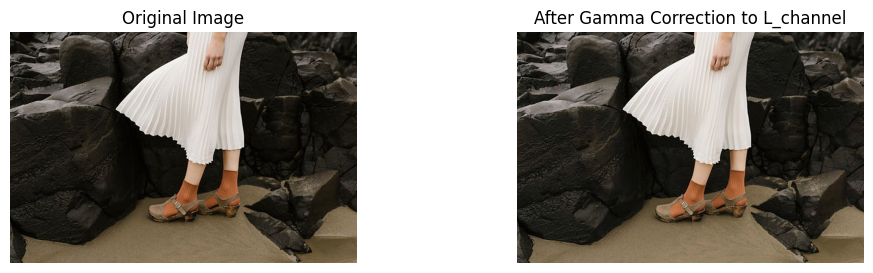

In [4]:
im = cv.imread("images\\3.jpeg")
im_LAB = cv.cvtColor(im,cv.COLOR_BGR2LAB)

fig,ax = plt.subplots(1,2,figsize = (12,3))
ax[0].imshow(cv.cvtColor(im,cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')

l_plane, a_plane, b_plane = cv.split(im_LAB)
gamma = 0.9
lut = np.array([((i/255.0)**gamma)*255 for i in range(0,256)]).astype("uint8")
l_corrected = cv.LUT(l_plane,lut)

im_LAB_corrected = cv.merge((l_corrected,a_plane,b_plane))


ax[1].imshow(cv.cvtColor(im_LAB_corrected,cv.COLOR_LAB2RGB))
ax[1].set_title('After Gamma Correction to L_channel')
ax[1].axis('off')


plt.show()


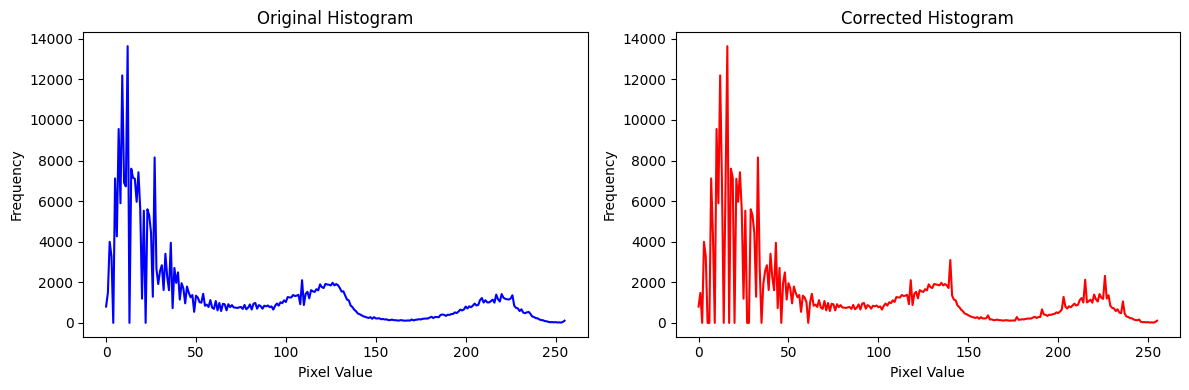

In [5]:
hist_orig = cv.calcHist([l_plane],[0],None,[256],[0,256])
hist_corr = cv.calcHist([l_corrected],[0],None,[256],[0,256])
fig,ax = plt.subplots(1,2,figsize = (12,4))
ax[0].plot(hist_orig, color='blue')
ax[0].set_title('Original Histogram')
ax[0].set_xlabel('Pixel Value')
ax[0].set_ylabel('Frequency')

ax[1].plot(hist_corr, color='red')
ax[1].set_title('Corrected Histogram')
ax[1].set_xlabel('Pixel Value')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

3. Increasing the vibrance of an image

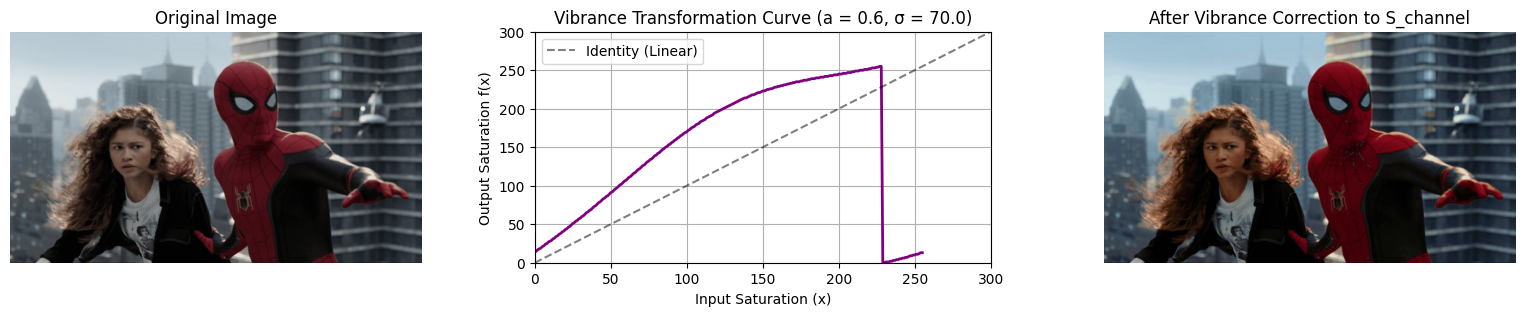

In [6]:
im  = cv.imread("images\\4.jpeg")
im_HSV = cv.cvtColor(im,cv.COLOR_BGR2HSV)

fig,ax = plt.subplots(1,3,figsize = (20,3))
ax[0].imshow(cv.cvtColor(im,cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')

# Split into Hue, Saturation, and Value channels
H_plane, S_plane, V_plane = cv.split(im_HSV)

a = 0.6
sigma = 70.0

#Applicatin of the Gaussian function to the Saturation channel for enhancement
lut = np.array([(i + a * 128.0 * np.exp(-((i - 128.0) ** 2) / (2 * (sigma ** 2)))) for i in range(0,256)]).astype("uint8")
S_corrected = cv.LUT(S_plane,lut)

im_HSV_corrected = cv.merge((H_plane,S_corrected,V_plane))
x = np.arange(256, dtype=np.float32)

ax[1].plot(x, lut, color='purple', linewidth=2)
ax[1].plot([0, 300], [0, 300], 'k--', alpha=0.5, label='Identity (Linear)')
ax[1].set_title(f'Vibrance Transformation Curve (a = {a}, σ = {sigma})')
ax[1].set_xlabel('Input Saturation (x)')
ax[1].set_ylabel('Output Saturation f(x)')
ax[1].set_xlim([0, 300])
ax[1].set_ylim([0, 300])
ax[1].grid(True)
ax[1].legend()


ax[2].imshow(cv.cvtColor(im_HSV_corrected,cv.COLOR_HSV2RGB))
ax[2].set_title('After Vibrance Correction to S_channel')
ax[2].axis('off')

plt.show()


Role of $a$: Parameter $a$ controls the strength of the saturation boost. Setting $a$ too high ($a > 0.8$) can cause clipping or unnatural color artifacts, while $a \approx 0.4 - 0.7$ gives a subtle, realistic vibrancy enhancement.  Why Saturation Plane? Applying this transform to the Saturation ($S$) plane modifies color intensity while keeping image luminance ($V$) and color tones ($H$) untouched

5. Histogram Equalization

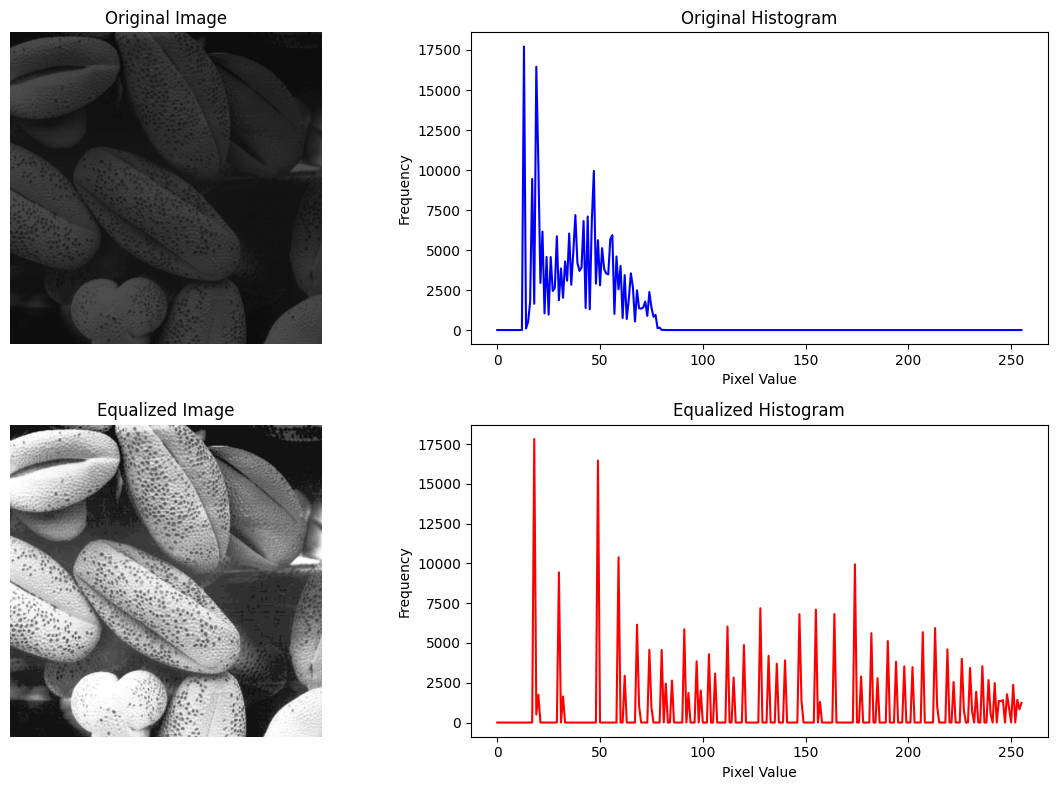

In [7]:
def custom_hitogram_equalization(im):
    hist, bins = np.histogram(im.flatten(), 256, [0, 256])

    cdf = np.cumsum(hist)/im.size  # Normalize the CDF to [0,1]
    lut = np.round(cdf * 255).astype(np.uint8)  # Scale to [0,255] and convert to uint8
    equalized_im = lut[im]

    return equalized_im

im = cv.imread("images\shells.tif", cv.IMREAD_GRAYSCALE)
equalized_im = custom_hitogram_equalization(im)
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0][0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[0][0].set_title('Original Image')
ax[0][0].axis('off')  # Hide axes for the original image
ax[1][0].imshow(equalized_im, cmap='gray', vmin=0, vmax=255)
ax[1][0].set_title('Equalized Image')
ax[1][0].axis('off')  # Hide axes for the equalized image


hist_orig,bins = np.histogram(im.flatten(), bins=256, range=[0, 256])
hist_eq, bins= np.histogram(equalized_im.flatten(), bins=256, range=[0, 256])


ax[0][1].plot(hist_orig, color='blue')
ax[0][1].set_title('Original Histogram')
ax[0][1].set_xlabel('Pixel Value')
ax[0][1].set_ylabel('Frequency')

ax[1][1].plot(hist_eq, color='red')
ax[1][1].set_title('Equalized Histogram')
ax[1][1].set_xlabel('Pixel Value')
ax[1][1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()




6. 


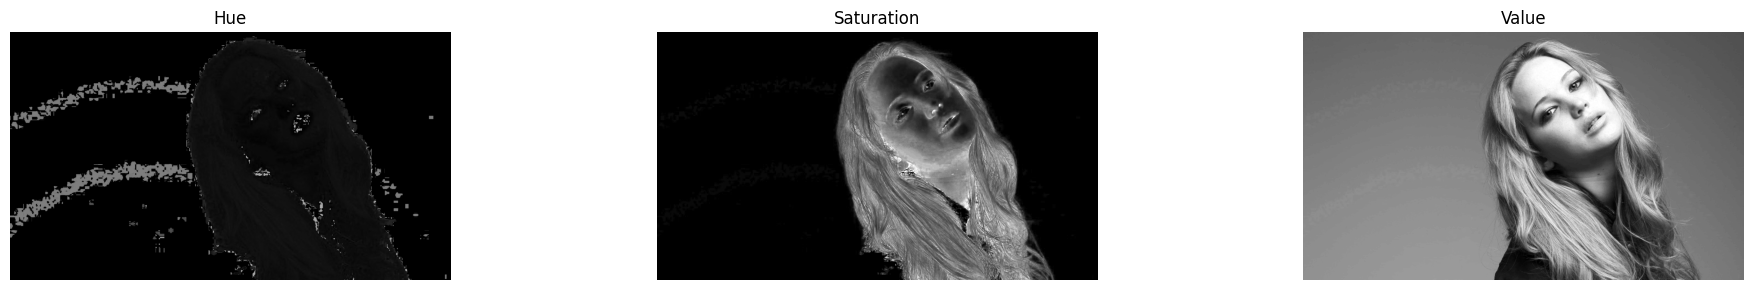

In [8]:
im = cv.imread("images\\7.jpeg")
im_HSV = cv.cvtColor(im,cv.COLOR_BGR2HSV)

H,S,V = cv.split(im_HSV)
fig,ax = plt.subplots(1,3,figsize=(20,3))

ax[0].imshow(H, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Hue')
ax[0].axis("off")
ax[1].imshow(S, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Saturation')
ax[1].axis("off")
ax[2].imshow(V, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Value')
ax[2].axis("off")

plt.tight_layout()
plt.show()

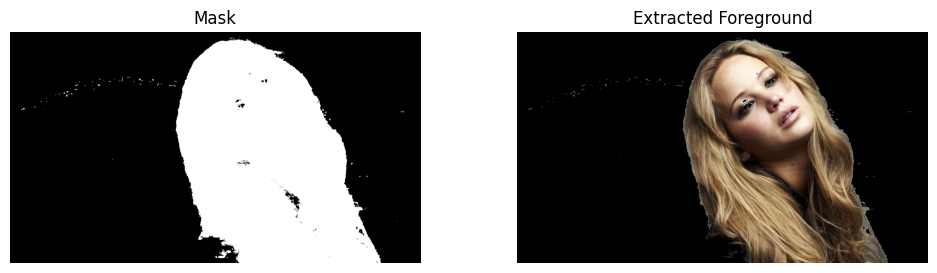

In [9]:

_, mask = cv.threshold(S, 12, 255, cv.THRESH_BINARY)

# Use bitwise_and to extract the foreground using the mask
foreground = cv.bitwise_and(im, im, mask=mask)

fig,ax = plt.subplots(1,2,figsize = (12,3))
ax[0].imshow(mask, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Mask')
ax[1].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
ax[1].set_title('Extracted Foreground')

for i in ax:
    i.axis('off')
plt.show()


Text(0, 0.5, 'Frequency')

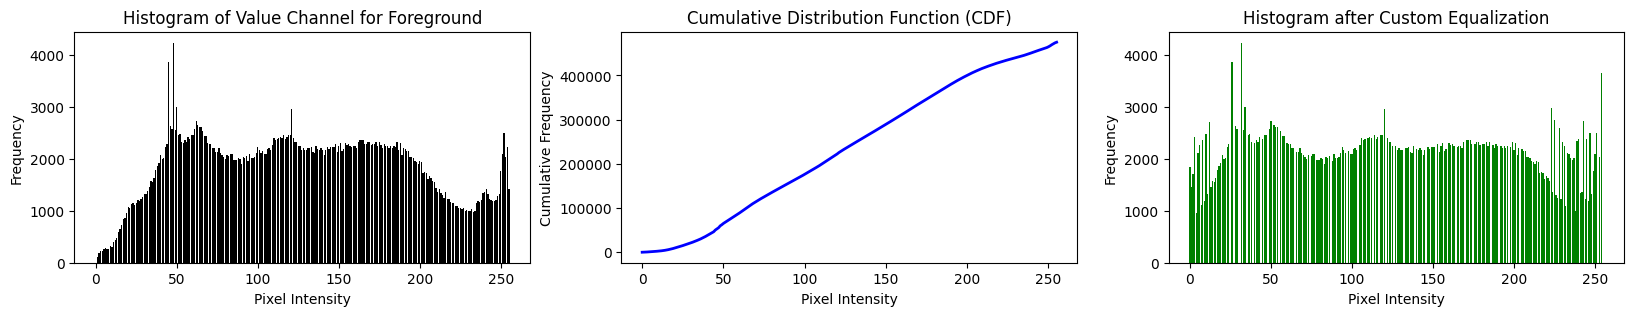

In [10]:
# Compute and plot the histogram of the Value (V) channel of the foreground
foreground_hsv = cv.cvtColor(foreground, cv.COLOR_BGR2HSV)
H_fg, S_fg, V_fg = cv.split(foreground_hsv)

# Calculate the histogram of the Value channel
hist = cv.calcHist([V_fg], [0], mask, [256], [0, 256])
cdf = hist.cumsum()

# Number of pixels
pixels = cdf[-1]

# Define transformation
t = np.array([(256-1)/(pixels)*cdf[k] for k in range(256)]).astype("uint8")

# Equalize
V_eq = t[V_fg]

# Calculate the histogram of the equalized Value channel
hist_equalized = cv.calcHist([V_eq], [0], mask, [256], [0, 256])


# Create an array for the x positions of the bars
x_positions = np.arange(256, dtype=np.float32)

fig,ax = plt.subplots(1,3,figsize = (20,3))
ax[0].bar(x_positions, hist.flatten(), color='black', linewidth=2)
ax[0].set_title('Histogram of Value Channel for Foreground')
ax[0].set_xlabel('Pixel Intensity')
ax[0].set_ylabel('Frequency')

ax[1].plot(x_positions, cdf.flatten(), color='blue', linewidth=2)
ax[1].set_title('Cumulative Distribution Function (CDF)')
ax[1].set_xlabel('Pixel Intensity')
ax[1].set_ylabel('Cumulative Frequency')    

ax[2].bar(x_positions, hist_equalized.flatten(), color='green', linewidth=2)
ax[2].set_title('Histogram after Custom Equalization')
ax[2].set_xlabel('Pixel Intensity')
ax[2].set_ylabel('Frequency')


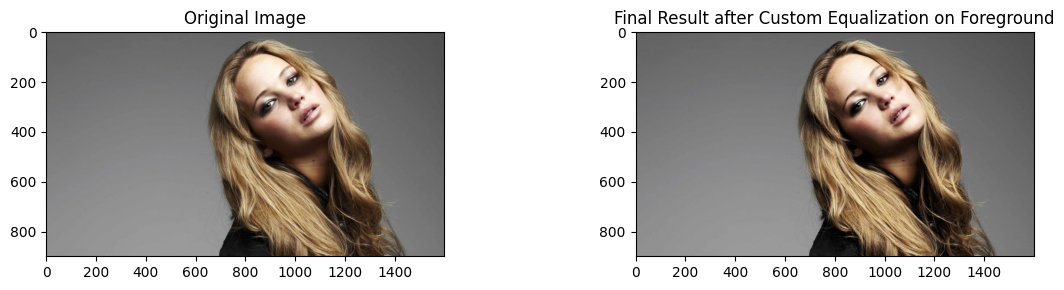

In [12]:
merged = cv.merge([H_fg,S_fg,V_eq])
modified_foreground = cv.cvtColor(merged,cv.COLOR_HSV2RGB)

background = cv.bitwise_and(im, im, mask=cv.bitwise_not(mask))
result = cv.add(cv.cvtColor(background, cv.COLOR_BGR2RGB), modified_foreground)

fig,ax = plt.subplots(1,2,figsize = (12,3))
ax[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[1].imshow(result)
ax[1].set_title('Final Result after Custom Equalization on Foreground') 

plt.tight_layout()
plt.show()